In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import colormaps as cm
import pandas as pd
import math
from graphcast.losses import normalized_latitude_weights

In [2]:
def plot_rmse(ax, prediction1, prediction2, target1, target2,
              pred1_label, pred2_label, var_name=None, 
              units=None, level=None, timestep="6h", forecast_days=10,):
    """Plot RMSE of two predictions against their targets on a given axis."""

    def compute_rmse(pred, target):
        return np.sqrt(((target - pred) ** 2).mean(dim=('time', 'lat', 'lon')))

    # compute rmse
    rmse1 = compute_rmse(prediction1, target1)
    rmse2 = compute_rmse(prediction2, target2)
    
    # convert lead time to hours/days
    lead_time_hours1 = prediction1["lead_time"].values / np.timedelta64(1, "h")
    lead_time_days1 = lead_time_hours1 / 24
    lead_time_hours2 = prediction2["lead_time"].values / np.timedelta64(1, "h")
    lead_time_days2 = lead_time_hours2 / 24
    
    # subsample to the end of every day
    steps_per_day = int(24 / int(timestep[:-1])) 
    ts_to_plot = np.arange(steps_per_day-1, forecast_days*steps_per_day, steps_per_day)

    # get values to plot
    values1 = rmse1.values[ts_to_plot]
    values2 = rmse2.values[ts_to_plot]
    
    days = lead_time_days1[ts_to_plot]

    # plot
    ax.plot(days, values1, linewidth=2, label=pred1_label)
    ax.plot(days, values2, linewidth=2, label=pred2_label)


    # axis labels
    xlabel = f"Forecast Lead Time [days]"
    ylabel = f"RMSE [{units}]" if units is not None else "RMSE"

    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)

    # axis ticks
    ax.tick_params(axis="both", labelsize=14,)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc='best', frameon=True)
    
    plt.tight_layout()
    
    return ax

In [14]:
def plot_lw_rmse(ax, prediction1, prediction2, target1, target2,
              pred1_label, pred2_label, var_name=None, 
              units=None, level=None, timestep="6h", forecast_days=10,):
    """Plot latitude weighted RMSE of two predictions against their targets on a given axis."""

    def compute_lw_rmse(pred, target):
        sqerr = (target - pred) ** 2
        sqerr *= normalized_latitude_weights(target).astype(sqerr.dtype)
        return np.sqrt((sqerr.mean(dim=("time", "lat", "lon"))))

    rmse1 = compute_lw_rmse(prediction1, target1)
    rmse2 = compute_lw_rmse(prediction2, target2)

    # convert lead time to hours/days
    lead_time_hours1 = prediction1["lead_time"].values / np.timedelta64(1, "h")
    lead_time_days1 = lead_time_hours1 / 24
    lead_time_hours2 = prediction2["lead_time"].values / np.timedelta64(1, "h")
    lead_time_days2 = lead_time_hours2 / 24
    
    # subsample to the end of every day
    steps_per_day = int(24 / int(timestep[:-1])) 
    ts_to_plot = np.arange(steps_per_day-1, forecast_days*steps_per_day, steps_per_day)

    # get values to plot
    values1 = rmse1.values[ts_to_plot]
    values2 = rmse2.values[ts_to_plot]
    
    days = lead_time_days1[ts_to_plot]

    # plot
    ax.plot(days, values1, linewidth=2, label=pred1_label)
    ax.plot(days, values2, linewidth=2, label=pred2_label)


    # axis labels
    xlabel = f"Forecast Lead Time [days]"
    ylabel = f"LW-RMSE [{units}]" if units is not None else "RMSE"

    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)

    # axis ticks
    ax.tick_params(axis="both", labelsize=14,)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc='best', frameon=True)
    
    plt.tight_layout()
    
    return ax

In [4]:
def plot_spatial_rmse(ax, prediction, target, label, lead_time=10, 
                      var_name=None, units=None, timestep="6h",):
    """Plot RMSE of two predictions against their targets on a given axis."""

    def compute_rmse(pred, target):
        return np.sqrt(((target - pred) ** 2).mean(dim=('time',)))

    # compute rmse
    rmse = compute_rmse(prediction, target)
    
    # time step to plot
    steps_per_day = int(24 / int(timestep[:-1])) 
    ts_to_plot = steps_per_day * lead_time # note that lead_time is in days

    # get values to plot
    da1 = rmse1.isel(lead_time=ts_to_plot)

    # plot
    da1.plot(ax=ax)
    


    # axis labels
    xlabel = f"Forecast Lead Time [days]"
    ylabel = f"RMSE [{units}]" if units is not None else "RMSE"

    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)

    # axis ticks
    ax.tick_params(axis="both", labelsize=14,)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc='best', frameon=True)
    
    plt.tight_layout()
    
    return ax

In [5]:
def plot_mae(ax, prediction1, prediction2, target1, target2,
             pred1_label, pred2_label, var_name=None, units=None, 
             level=None):
    """Plot MAE of two predictions against target on a given axis."""

    def compute_mae(pred, target):
        abs_error = abs(target - pred)
        return abs_error.mean(dim=("time", "lat", "lon"))

    mae1 = compute_mae(prediction1, target1)
    mae2 = compute_mae(prediction2, target2)

    ax.plot(mae1, linewidth=2, label=pred1_label)
    ax.plot(mae2, linewidth=2, label=pred2_label)

    ax.set_xticks(np.arange(3, 40, 4))
    ax.set_xticklabels(np.arange(1, 11))
    ax.set_xlabel("Lead time (in days)", fontsize=12)

    ylabel = f"MAE (in {units})" if units else "MAE"
    ax.set_ylabel(ylabel, fontsize=12)

    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc='best', frameon=True)
    
    plt.tight_layout()

    return ax

In [6]:
def plot_lw_mae(ax, prediction1, prediction2, target1, target2,
                pred1_label, pred2_label, var_name=None, units=None, 
                level=None):
    """Plot grid-cell weighted MAE of two predictions against target on a given axis."""

    def compute_lw_mae(pred, target):
        abs_error = abs(target - pred)
        abs_error *= normalized_latitude_weights(target).astype(abs_error.dtype)
        return abs_error.mean(dim=("time", "lat", "lon"))

    mae1 = compute_lw_mae(prediction1, target1)
    mae2 = compute_lw_mae(prediction2, target2)

    ax.plot(mae1, linewidth=2, label=pred1_label)
    ax.plot(mae2, linewidth=2, label=pred2_label)

    ax.set_xticks(np.arange(3, 40, 4))
    ax.set_xticklabels(np.arange(1, 11))
    ax.set_xlabel("Lead time (in days)", fontsize=12)

    ylabel = f"LW-MAE (in {units})" if units else "LW-MAE"
    ax.set_ylabel(ylabel, fontsize=12)

    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    if var_name:
        title = var_name
        if level is not None:
            title += f", level={level:.2f}"
        ax.set_title(title, fontsize=12, fontweight="bold")

    ax.legend(loc='best', frameon=True)
    
    plt.tight_layout()
    
    return ax

In [7]:
# metadata
_scratch = "/pscratch/sd/n/nagarwal/"

_prototype1 = "ocn-only"; _expt1 = "R5"; _sub_expt1 = "T1M"; expt_name1 = "24h no-bathy"
_prototype2 = "ocn-only"; _expt2 = "R7"; _sub_expt2 = "T1M"; expt_name2 = "24h with-bathy "
_prototype_home = "/global/homes/n/nagarwal/graph-ufs/prototypes/"

_inference1_dir = os.path.join(_scratch, _prototype1, _expt1, 
                               f"inference_{_sub_expt1}", "validation")
_inference2_dir = os.path.join(_scratch, _prototype2, _expt2, 
                               f"inference_{_sub_expt2}", "validation")

_figdir = os.path.join(os.getcwd(), "figures")

In [8]:
# GraphUFS predictions and targets

# Expt 1
fcast_length = "240h"
ds_pred1 = xr.open_zarr(os.path.join(_inference1_dir, f"graphufs.{fcast_length}.zarr"))
ds_tar1 = xr.open_zarr(os.path.join(_inference1_dir, f"replay.{fcast_length}.zarr"))

# Expt 2
fcast_length = "960h"
ds_pred2 = xr.open_zarr(os.path.join(_inference2_dir, f"graphufs.{fcast_length}.zarr"))
ds_tar2 = xr.open_zarr(os.path.join(_inference2_dir, f"replay.{fcast_length}.zarr"))

# Sube

In [9]:
vcoord = "z_l"
coords = ["lat", "lon", vcoord, "time", "lead_time"]
common_vars = [v for v in ds_pred1.variables if v in ds_pred2.variables and v not in coords]
common_vars_3d = [v for v in common_vars if vcoord in ds_pred2[v].coords]
common_vars_2d = list(set(common_vars) - set(common_vars_3d))

# RMSE

### No Latitude Weighting

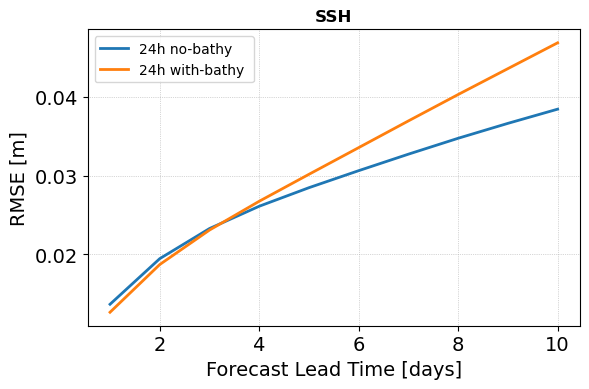

In [10]:
# plot -- 2D variables 
nvars = len(common_vars_2d)
ncols = math.ceil(math.sqrt(nvars)) # make a square-ish box
nrows = math.ceil(nvars / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*4))
if nrows*ncols > 1:
    axes = np.array(axes).flatten()

for i, v in enumerate(common_vars_2d):
    ax = axes[i] if nrows*ncols > 1 else axes
    _ = plot_rmse(ax, ds_pred1[v], ds_pred2[v], ds_tar1[v], ds_tar2[v], expt_name1, expt_name2,
                  var_name=v, units=ds_tar1[v].units, timestep="24h", forecast_days=10)

if nrows*ncols > 1:
    for j in range(nvars, len(axes)): # turn off the unused axes
        axes[j].axis("off")

plt.tight_layout()
#plt.savefig("figures/RMSEs_atm-only_vs_atm-wocnsfc_2d_atm_vars.png", dpi=300)
plt.show()

### Latitude Weighted

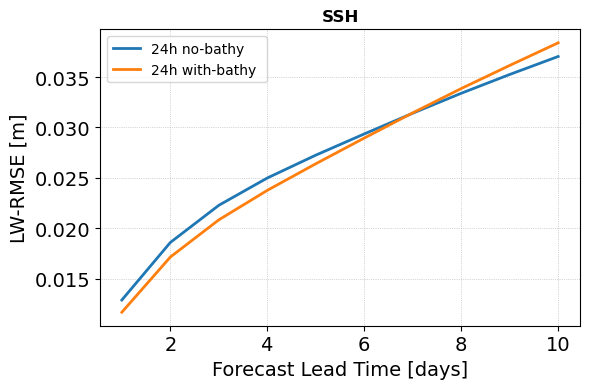

In [15]:
nvars = len(common_vars_2d)
ncols = math.ceil(math.sqrt(nvars)) # make a square-ish box
nrows = math.ceil(nvars / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*4))
if nrows*ncols > 1:
    axes = np.array(axes).flatten()

for i, v in enumerate(common_vars_2d):
    ax = axes[i] if nrows*ncols > 1 else axes
    _ = plot_lw_rmse(ax, ds_pred1[v], ds_pred2[v], ds_tar1[v], ds_tar2[v], expt_name1, expt_name2,
                     var_name=v, units=ds_tar1[v].units, timestep="24h", forecast_days=10)

if nrows*ncols > 1:
    for j in range(nvars, len(axes)): # turn off the unused axes
        axes[j].axis("off")

plt.tight_layout()
#plt.savefig("figures/RMSEs_atm-only_vs_atm-wocnsfc_2d_atm_vars.png", dpi=300)
plt.show()

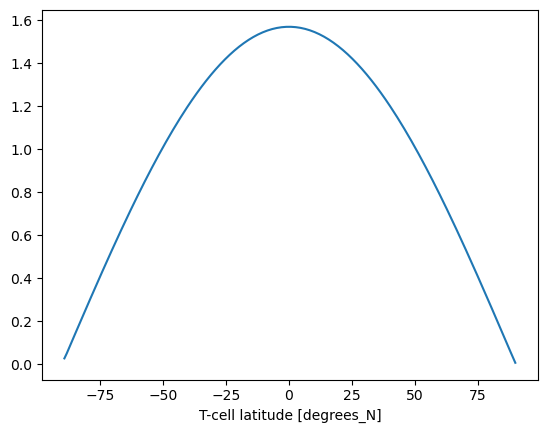

In [13]:
latitude_weights = normalized_latitude_weights(ds_tar1)
latitude_weights.plot()
plt.show()

### Spatial RMSE

In [16]:
# Open the existing atm zarr-store
atm = xr.open_zarr(
    "gs://noaa-ufs-gefsv13replay/ufs-hr1/0.25-degree-subsampled/03h-freq/zarr/fv3.zarr",
    storage_options={"token": "anon"},
)
atm

<xarray.Dataset> Size: 60TB
Dimensions:        (time: 87020, grid_yt: 192, grid_xt: 384, pfull: 127)
Coordinates:
    cftime         (time) object 696kB dask.array<chunksize=(21755,), meta=np.ndarray>
    ftime          (time) timedelta64[ns] 696kB dask.array<chunksize=(21755,), meta=np.ndarray>
  * grid_xt        (grid_xt) float64 3kB 0.0 0.9375 1.875 ... 357.2 358.1 359.1
  * grid_yt        (grid_yt) float64 2kB 89.82 88.89 87.95 ... -88.18 -89.12
  * pfull          (pfull) float32 508B 0.01278 0.02033 0.03177 ... 996.2 998.8
  * time           (time) datetime64[ns] 696kB 1993-12-31T18:00:00 ... 2023-1...
Data variables: (12/183)
    acond          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    albdo_ave      (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alnsf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alnwf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alvsf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alvwf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    ...             ...
    xtts           (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xu             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xv             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xz             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xzts           (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    zc             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
Attributes:
    abstract:         The NOAA Unified Forecast System (UFS) / Global Ensembl...
    acknowledgement:  To provide appropriate attribution under this license, ...
    description:      This zarr store is a subset of the original GEFSv13 UFS...
    license:          The Global Ensemble Forecast System version 13 (GEFSv13...

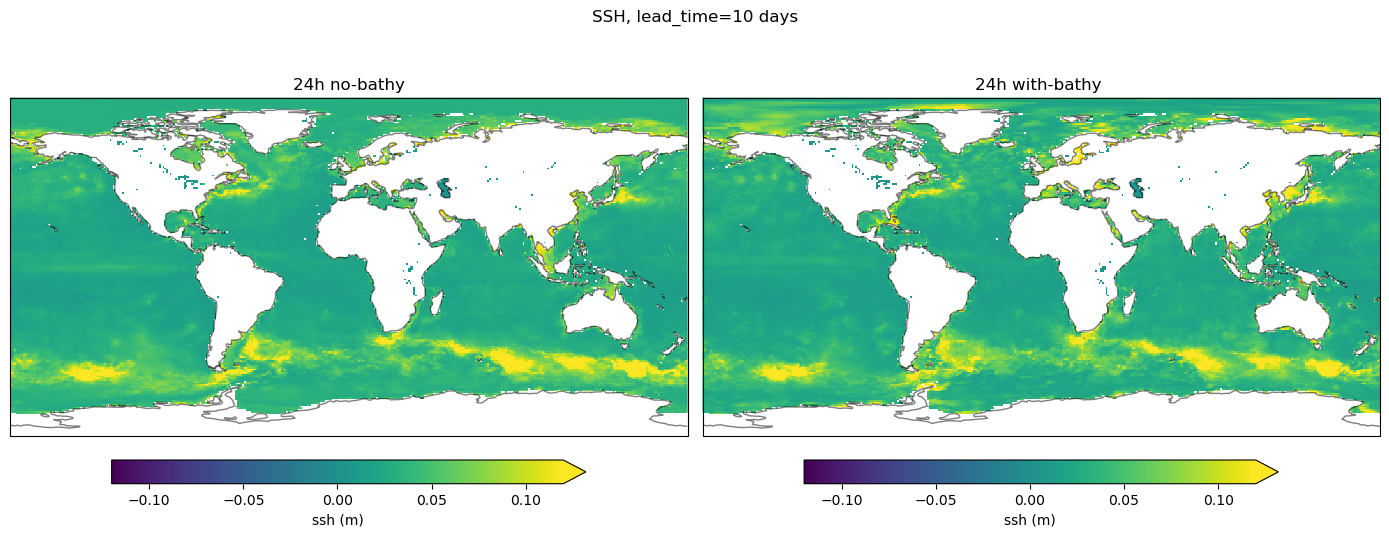

In [20]:
## Spatial RMSE plot comparison -- for 10 day lead time
ileadtime = 9 
leadtime = int(ds_pred1.lead_time[ileadtime].values/3600/1e9/24)

fig, axs = plt.subplots(1, 2, figsize=(14,5.5), subplot_kw=dict(projection=ccrs.PlateCarree()))
kwargs = {"cbar_kwargs":{"orientation": "horizontal", "shrink":0.7, "label":"ssh (m)", "pad":0.05}, 
          "robust":True, "cmap":"viridis", "vmin":-0.12, "vmax":0.12,}

ocean_mask = 1-atm.land_static.rename({"grid_xt":"lon", "grid_yt":"lat"})

# RMSE -- prototype 1
sqerror = (ds_pred1["SSH"].isel(lead_time=ileadtime) - ds_tar1["SSH"].isel(lead_time=ileadtime))**2
rmse1 = np.sqrt(sqerror.mean(dim=('time',)))
rmse1 = rmse1.where(ocean_mask)

rmse1.plot(ax=axs[0], transform=ccrs.PlateCarree(), **kwargs)
axs[0].coastlines(alpha=0.5)
axs[0].set_title(f"{expt_name1}")

# RMSE -- prototype 2
sqerror = (ds_pred2["SSH"].isel(lead_time=ileadtime) - ds_tar2["SSH"].isel(lead_time=ileadtime))**2
rmse2 = np.sqrt(sqerror.mean(dim=('time',)))
rmse2 = rmse2.where(ocean_mask)

rmse2.plot(ax=axs[1], transform=ccrs.PlateCarree(), **kwargs)
axs[1].coastlines(alpha=0.5)
axs[1].set_title(f"{expt_name2}")

plt.suptitle(f"SSH, lead_time={leadtime} days")
plt.tight_layout()
#plt.savefig(os.path.join(_figdir, f"{variable}_{_prototype}_{_expt}.png"), dpi=300)
plt.show()

# MAE

# Co-variability